# Experiment 3 — can routine-maintenance crowd-out be measured?

**Result: not yet in this pilot.** We recovered useful budget components and documentary evidence of capital delays, but no certified same-year routine-maintenance budget/actual pair. No causal or ML model is fitted.

Three affected councils: Eurobodalla (2019–20), Lismore and Richmond Valley (2021–22). Three provisional comparisons: Griffith, Kiama and Wagga Wagga. Experiments 1 and 2 remain frozen.

## 1. Define the outcome before modelling

`maintenance_deviation = (actual routine − original planned routine) / original planned routine`

The plan must predate the disaster, the denominator must be positive, and both amounts must use the same year, asset/fund/work scope with disaster reconstruction excluded. Required maintenance in the OLG adequacy ratio is **not** this budget. Unknown amounts remain blank, not zero. Read [the measurement rules](results/measurement_quality.md) for source-specific decisions.

In [1]:
from pathlib import Path
import json, runpy
import pandas as pd
from IPython.display import display, Image

root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'NSW Data Panel.csv').exists())
out = root / 'Experiment 3/results'
# Rebuild only this experiment from cached evidence; no network access or models.
from contextlib import redirect_stdout
import io
with redirect_stdout(io.StringIO()):
    runpy.run_path(str(out / 'build_workflow.py'))
checks = json.loads((out / 'validation_checks.json').read_text())
display(pd.read_csv(out / 'coverage_summary.csv'))

,role,councils,council_years,primary_pairs,observed_aggregate_maintenance
0,candidate_comparison,3,18,0,17
1,treated,3,18,0,18


## 2. What was actually recovered?

The ledger distinguishes routine candidates, mixed spending, capital works, damage and funding. Lismore's budget has actual **2020–21**, original budget **2021–22**, and draft budget **2022–23** in adjacent columns. Pairing those columns would create a false outcome. The table below is a small extract; every observation and its exclusion reason is saved.

,council_key,financial_year,field,value,accounting_category,page_or_table
1,lismore,2021-22,planned_routine_component_candidate,1506600.0,routine_candidate,PDF p33 / Roads / Original Budget 2021/22
10,richmondvalley,2021-22,planned_routine_component_candidate,439782.0,routine_candidate,PDF p18 / Operating expenditure / 2021/2022
16,richmondvalley,2021-22,reported_capital_underspend,17030000.0,capital_works,PDF p30 / printed p29 / B5-1
24,lismore,2021-22,routine_budget_actual_pair,NaN,unknown,"PDF pp3,14,16,21,29; full-report keyword review"
27,lismore,2022-23,revised_disaster_operating_budget,18500000.0,reconstruction_or_emergency_mixture,PDF p17 / printed p15 / Revised Budget 31-Mar-23


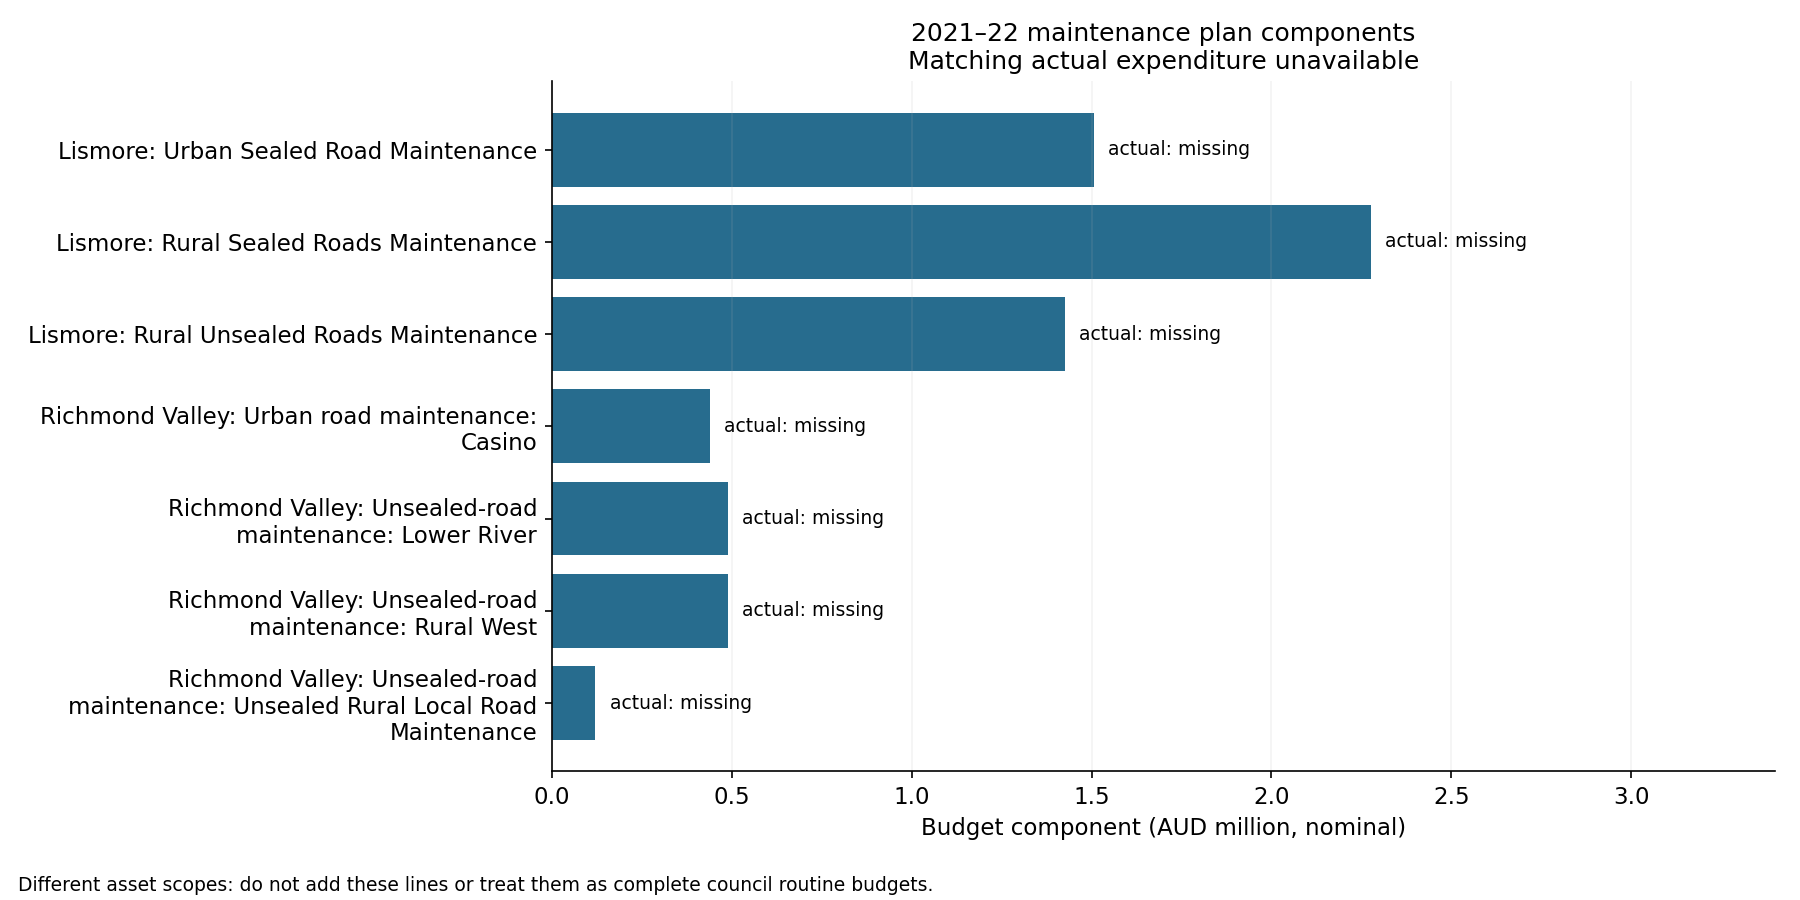

In [2]:
evidence = pd.read_csv(out / 'documentary_evidence.csv')
fields = ['council_key', 'financial_year', 'field', 'value', 'accounting_category', 'page_or_table']
display(evidence.loc[evidence.evidence_id.isin(['E002','E011','E017','E025','E028']), fields])
display(Image(filename=str(out / 'figures/planned_vs_actual_routine.png')))

## 3. Comparison councils and pre-trends

Screen all 103 continuing councils using pre-event maintenance, fiscal characteristics, scale and prior exposure. Concurrent exposure is used only to exclude contaminated controls. Candidates are not automatically valid controls: physical flood absence and geographic comparability remain unverified, and all selected candidates have a later disaster declaration in follow-up.

The plot shows **aggregate**, nominal maintenance across three pre-years. It cannot certify routine-maintenance parallel trends.

,treated_council_key,candidate_council_key,pre_only_distance,feature_count,post_window_any_declared
36,eurobodalla,griffith,0.531,10,True
44,eurobodalla,kiama,0.551,10,True
190,lismore,waggawagga,0.328,11,True
292,richmondvalley,waggawagga,0.542,11,True


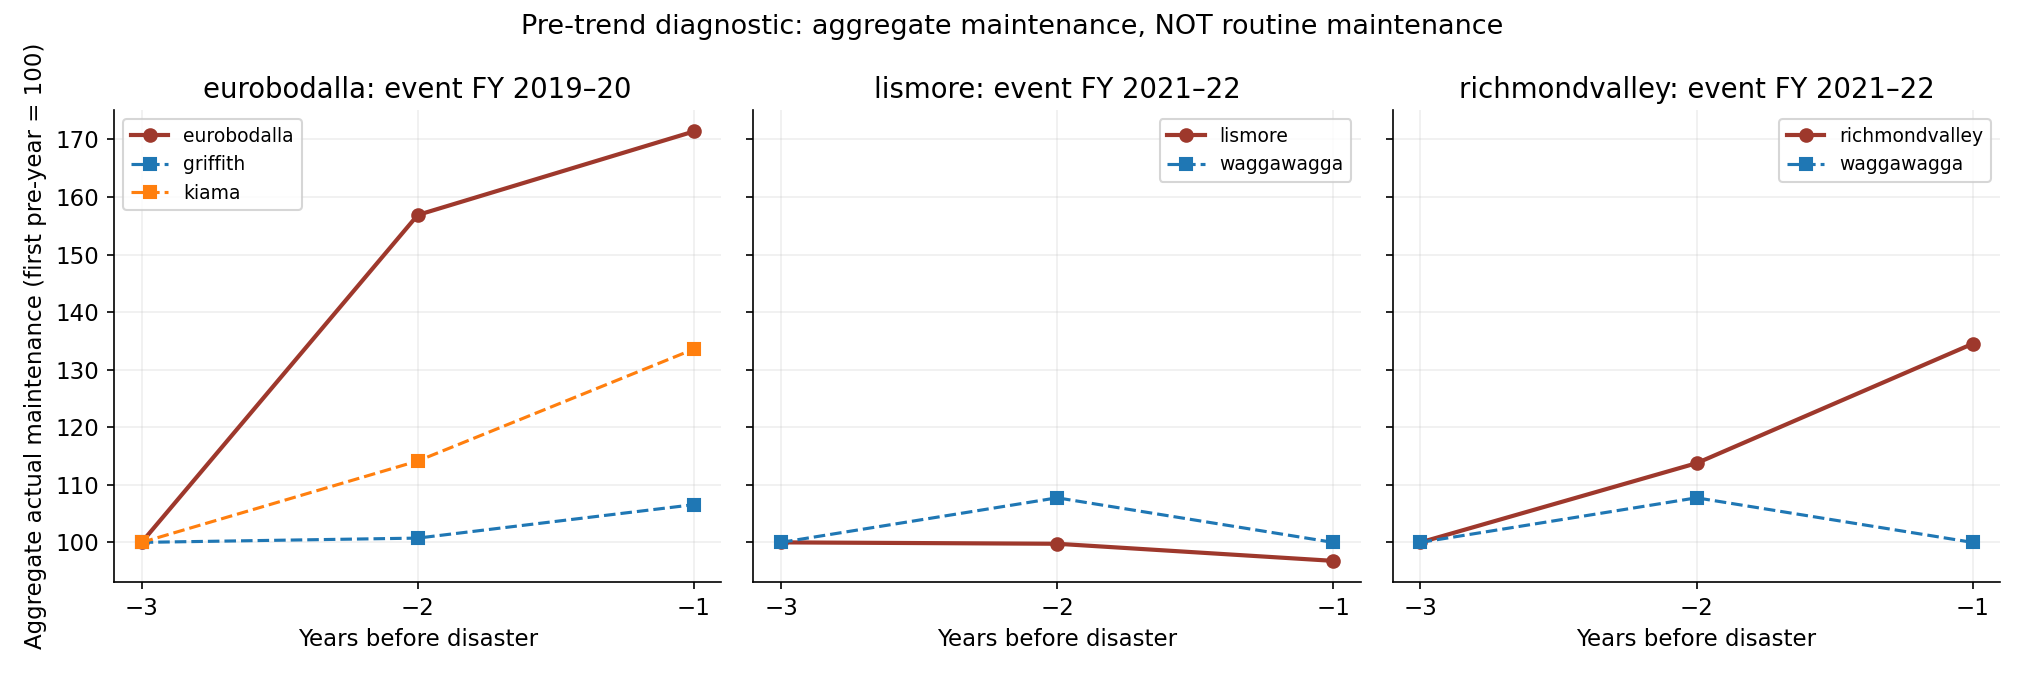

In [3]:
candidates = pd.read_csv(out / 'comparison_candidates.csv')
chosen = candidates[candidates.selected_for_document_review]
display(chosen[['treated_council_key','candidate_council_key','pre_only_distance','feature_count','post_window_any_declared']].round(3))
display(Image(filename=str(out / 'figures/treated_comparison_pretrends.png')))

## 4. Apply the modelling gate

No complete routine outcome passes the measurement gate. The three affected councils cover only two event groups. None has pre-event cash cover below the pre-specified three-month threshold. No fiscal interaction or funding effect can be estimated credibly.

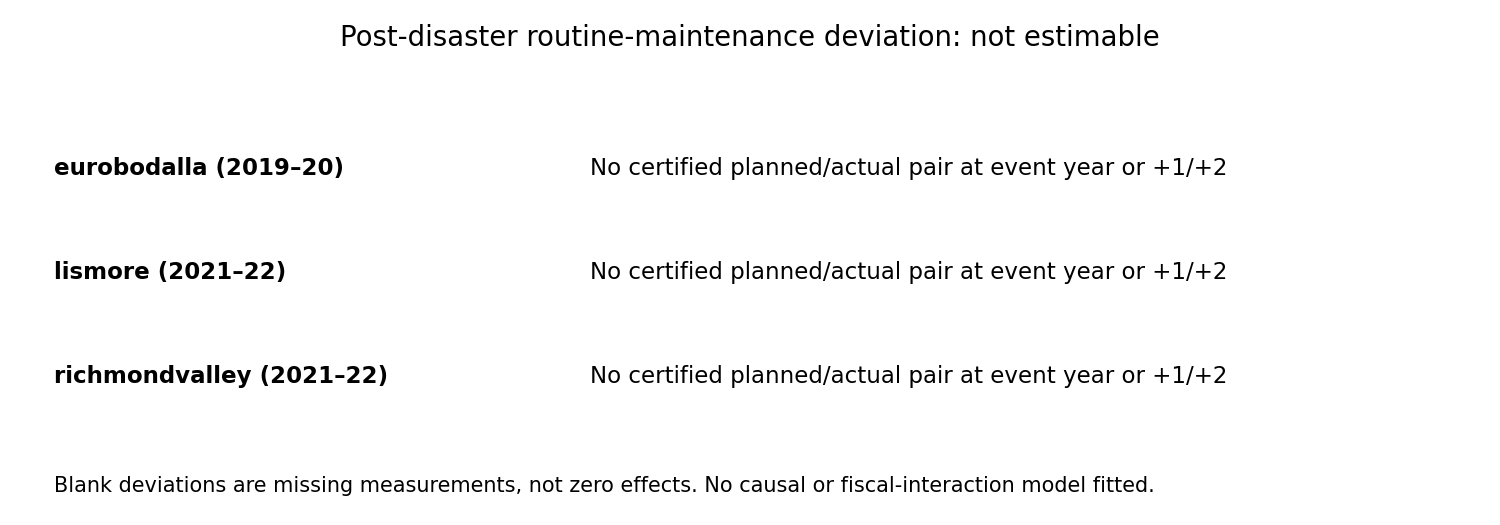

In [4]:
panel = pd.read_csv(out / 'experiment3_panel.csv')
assert not panel.primary_outcome_eligible.any()
assert panel.maintenance_deviation.isna().all()
assert checks['models_fitted'] == 0
assert checks['existing_files_changed'] == []
display(Image(filename=str(out / 'figures/post_disaster_deviation_status.png')))

## 5. Findings A–F

**A — Measurement:** Budget lines can sometimes be separated, but matching actuals and scope reconciliation are missing. No primary outcome observations are certified.

**B — Comparisons:** No credible causal comparison set yet. The apparent candidates have outcome-definition gaps, some divergent aggregate pre-trends and later disaster exposure.

**C — Crowd-out:** Capital disruption is documented; routine-maintenance crowd-out is not established. Eurobodalla also reports scheduled road maintenance completed.

**D — Fiscal capacity:** Not estimable. Keep cash cover and operating position separate; do not substitute post-disaster grants or liquidity.

**E — Advance funding:** NO-GO. Lismore reports $86m received during FY2023–24, but exact first payment and project linkage are unresolved. Its $860m announcement is not a payment record.

**F — Next data:** Obtain original budgets, monthly work-code ledgers, deferred-task records, event-linked damage and bank-dated project funding for treated councils and credible controls.

**Verdict: NO-GO for causal estimation; GO for targeted ledger collection.** This is an inconclusive measurement result, not evidence that no crowd-out occurs.

[Full source-linked verdict](results/measurement_quality.md) · [All files and reproduction](results/README.md)